# Regression - Model training and Evaluation

- Dependent variable (y) - predict
- Independent variable (x) - used to predict y

simple linear regression: 
* y = mx+c 
* y = m1x1 + m2x2 + m3x3 + c
* y = m.x.^3 + m2x2^2 + m3x3 + c

Evaluation ways
* MAE - mean abosolute error AVG(y-ypred)
* MSE - Mean squared error (AVG(y-ypred)^2)
* R2 score

#### Finding of R2 score
- R2 = 1- (SSres/Sum of square of total)

In [3]:
import pandas as pd
import numpy as np 

df = pd.read_csv('Book2.csv')
df.head(2)



,x,y
0,15,49
1,23,63


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   x       15 non-null     int64
 1   y       15 non-null     int64
dtypes: int64(2)
memory usage: 372.0 bytes


In [5]:
df.isna().sum()

x    0
y    0
dtype: int64

In [6]:
print(type(df['x']))
print(type(df['y']))



<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


##### we need x as df and y as series so chaigning them and let's do it

In [7]:
x = df.iloc[:,0:1] # second slicing operator for the type change
y = df.iloc[:,-1] 

print(type(x))
print(type(y))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [8]:
# doing it without test the csv way
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x,y)
y_pred = lr.predict(x)
print(y_pred)


[47.45652174 62.60810811 53.13836663 62.60810811 64.5020564  60.71415981
 60.71415981 55.03231492 55.03231492 49.35047004 64.5020564  39.88072855
 64.5020564  49.35047004 62.60810811]


In [9]:
# difference 
diff = pd.DataFrame({'Actual': y, 'Predict': y_pred})
diff.head()

,Actual,Predict
0,49,47.456522
1,63,62.608108
2,58,53.138367
3,60,62.608108
4,58,64.502056


In [10]:
# errors
print('Coefficent ', lr.coef_)
print('Intercept: ',lr.intercept_)


Coefficent  [1.8939483]
Intercept:  19.04729729729729


In [11]:
# erros 2
from sklearn import metrics
print(f'MAR: {metrics.mean_absolute_error(y,y_pred)}')
print(f'MAS: {metrics.mean_squared_error(y,y_pred)}')
print(f'R2 Score: {metrics.r2_score(y,y_pred)}')

MAR: 3.7412847630238937
MAS: 22.292068155111632
R2 Score: 0.7088287858527739


In [12]:
# 

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1, random_state=1)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(13, 1)
(2, 1)
(13,)
(2,)


In [13]:
lr = LinearRegression()
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)
print(y_pred)


[62.41322902 54.56827881]


In [14]:
# difference 
diff = pd.DataFrame({'Actual': y_test, 'Predict': y_pred})
diff.head()

,Actual,Predict
3,60,62.413229
7,63,54.568279


In [15]:
# errors
print('Coefficent ', lr.coef_)
print('Intercept: ',lr.intercept_)


Coefficent  [1.96123755]
Intercept:  17.30476529160738


In [16]:
# erros 2
from sklearn import metrics
print(f'MAE: {metrics.mean_absolute_error(y_test,y_pred)}')
print(f'MAS: {metrics.mean_squared_error(y_test,y_pred)}')
print(f'R2 Score: {metrics.r2_score(y_test,y_pred)}')

MAE: 5.422475106685635
MAS: 38.458798301932994
R2 Score: -16.092799245303553


#### example

In [17]:
import pandas as pd 
import numpy as np 

df = pd.DataFrame({'Hours Studied': [1,2,3,4,5,6,7], 
                    'Exam Score': [50,55,65,70,75,80,85]})
df

,Hours Studied,Exam Score
0,1,50
1,2,55
2,3,65
3,4,70
4,5,75
5,6,80
6,7,85


## Process
1. DataFrame
2. info(),isna() for cleaning
3. define x,y
4. Train test (if needed)
5. Regression mode
6. Predicition
7. DataFrame(y/ytest, y_pred)
8. coef_,intercept
9. MAE,MSE,R2 score

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Hours Studied  7 non-null      int64
 1   Exam Score     7 non-null      int64
dtypes: int64(2)
memory usage: 244.0 bytes


In [19]:
df.isna().sum()

Hours Studied    0
Exam Score       0
dtype: int64

#### can use df[['name']] for df and df['name'] for series

In [20]:
x= df.iloc[:,0:1]
y = df.iloc[:,-1]

In [21]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x,y)

y_pred = lr.predict(x)
print(y_pred)

[50.89285714 56.78571429 62.67857143 68.57142857 74.46428571 80.35714286
 86.25      ]


In [22]:
diff = pd.DataFrame({'Actual': y, 'Predict': y_pred})
diff.head()

,Actual,Predict
0,50,50.892857
1,55,56.785714
2,65,62.678571
3,70,68.571429
4,75,74.464286


In [23]:
print('Coeffiecent',lr.coef_)
print('Intercept',lr.intercept_)

Coeffiecent [5.89285714]
Intercept 45.0


In [24]:
# Metrics
from sklearn import metrics as m 

print(f'MAE: {m.mean_absolute_error(y,y_pred)}')
print(f'MAS: {m.mean_squared_error(y,y_pred)}')
print(f'R2 Score: {m.r2_score(y,y_pred)}')

MAE: 1.2244897959183672
MAS: 1.9132653061224514
R2 Score: 0.9864130434782609


## Graphical Representation of a REgression Model

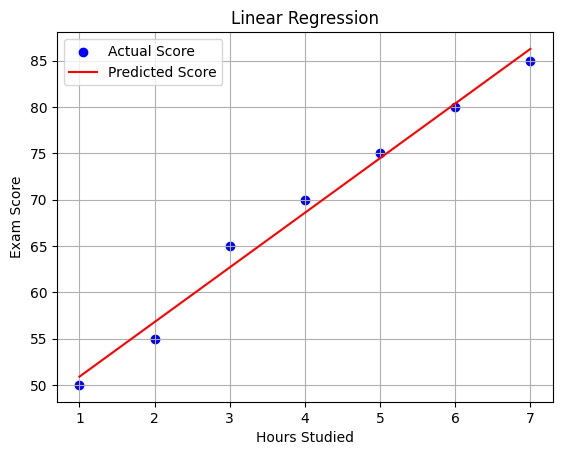

In [25]:
from sqlalchemy import label
import matplotlib.pyplot as plt 
plt.scatter(x,y,color='blue',label='Actual Score')
plt.plot(x,y_pred,color='red',label='Predicted Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Linear Regression')
plt.legend()
plt.grid(True)
plt.show()

### example

In [26]:
df = pd.read_csv('Book1.csv')
df

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cgpa     200 non-null    float64
 1   package  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [28]:
df.isna().sum()

cgpa       0
package    0
dtype: int64

In [29]:
x = df[['cgpa']]
y = df['package']


In [30]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=19,test_size=0.3)
print(x_train.shape)
print(y_train.shape)

(140, 1)
(140,)


In [31]:
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)
y_pred

array([4.38187377, 3.5439274 , 2.65467819, 2.58057409, 2.98529648,
       2.35826179, 3.35011667, 3.18480753, 2.39246368, 4.12535957,
       3.65223339, 2.79148576, 2.93399365, 2.56347314, 2.39816399,
       4.34197156, 3.4698233 , 2.83138797, 3.23611036, 2.72308197,
       3.09360248, 2.23285485, 2.64897787, 3.01379806, 2.56347314,
       2.96249522, 3.34441636, 1.64002204, 2.3639621 , 2.62617661,
       1.95353939, 2.15875074, 3.21900942, 3.23041005, 3.77194002,
       3.73773812, 2.50646999, 3.2133091 , 3.23041005, 2.26135642,
       3.07080122, 2.88269081, 3.84604412, 3.93724916, 2.97959617,
       3.139205  , 3.44132172, 3.18480753, 3.49262456, 3.46412298,
       2.98529648, 2.88839112, 3.19050784, 2.38676336, 3.18480753,
       2.55207251, 2.01624286, 3.19620816, 3.08790216, 3.53822708])

In [32]:
diff = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
diff.head()

,Actual,Predicted
40,4.02,4.381874
140,3.15,3.543927
33,2.73,2.654678
91,2.14,2.580574
13,2.89,2.985296


In [33]:
print('Coreffiecnt',lr.coef_)
print('Intercept',lr.intercept_)

Coreffiecnt [0.57003154]
Intercept -0.9650221207944085


In [34]:
print(f'MAE: {m.mean_absolute_error(y_test,y_pred)}')
print(f'MAS: {m.mean_squared_error(y_test,y_pred)}')
print(f'R2 Score: {m.r2_score(y_test,y_pred)}')

MAE: 0.21067086672666643
MAS: 0.07398322282163168
R2 Score: 0.8104816443521474


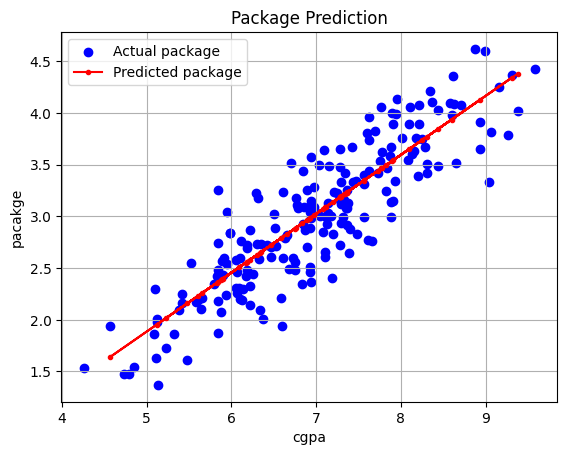

In [35]:

plt.scatter(x,y,color='blue',label='Actual package')
plt.plot(x_test,y_pred,color='red',label='Predicted package',marker='.')
plt.legend()
plt.xlabel('cgpa')
plt.ylabel('pacakge')
plt.title('Package Prediction')
plt.grid(True)
plt.show()

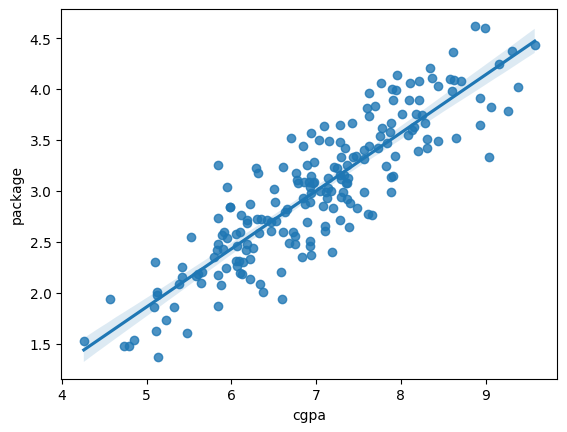

In [36]:
## REgression plot
import seaborn as sns 
sns.regplot(df,x='cgpa',y='package')
plt.show()

## Predict using user input

In [37]:
n = float(input('Enter ur cgpa: '))
y_pred = lr.predict([[n]])
print('Your package will be: ',y_pred)

ValueError: could not convert string to float: ''

## Multiple Linear Regression

In [ ]:
df = pd.read_csv("car data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
df.drop(columns=['Car_Name'],inplace=True)

In [ ]:
# one hot encoding
df = pd.get_dummies(df, columns=['Fuel_Type','Seller_Type','Transmission'], drop_first=True, dtype=int)
df

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,0,0,1,0,1
1,2013,4.75,9.54,43000,0,1,0,0,1
2,2017,7.25,9.85,6900,0,0,1,0,1
3,2011,2.85,4.15,5200,0,0,1,0,1
4,2014,4.60,6.87,42450,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...
296,2016,9.50,11.60,33988,0,1,0,0,1
297,2015,4.00,5.90,60000,0,0,1,0,1
298,2009,3.35,11.00,87934,0,0,1,0,1
299,2017,11.50,12.50,9000,0,1,0,0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Year                    301 non-null    int64  
 1   Selling_Price           301 non-null    float64
 2   Present_Price           301 non-null    float64
 3   Kms_Driven              301 non-null    int64  
 4   Owner                   301 non-null    int64  
 5   Fuel_Type_Diesel        301 non-null    int64  
 6   Fuel_Type_Petrol        301 non-null    int64  
 7   Seller_Type_Individual  301 non-null    int64  
 8   Transmission_Manual     301 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 21.3 KB


In [ ]:
df.isna().sum()

Year                      0
Selling_Price             0
Present_Price             0
Kms_Driven                0
Owner                     0
Fuel_Type_Diesel          0
Fuel_Type_Petrol          0
Seller_Type_Individual    0
Transmission_Manual       0
dtype: int64

In [ ]:
# Feature Transformation
df['age'] = 2026 -df['Year']
df.drop(columns=['Year'],inplace=True)
df.head()

,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual,age
0,3.35,5.59,27000,0,0,1,0,1,12
1,4.75,9.54,43000,0,1,0,0,1,13
2,7.25,9.85,6900,0,0,1,0,1,9
3,2.85,4.15,5200,0,0,1,0,1,15
4,4.60,6.87,42450,0,1,0,0,1,12


In [ ]:
x = df[['age','Present_Price','Kms_Driven','Fuel_Type_Diesel','Fuel_Type_Petrol','Seller_Type_Individual','Transmission_Manual','Owner']]
# or x = df.drop('Selling_Price',axis=1)
y = df['Selling_Price']

In [ ]:
from sklearn import metrics
m = {}
for  i in range(43):
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3, random_state=i)
    lr = LinearRegression()
    lr.fit(x_train,y_train)
    y_pred = lr.predict(x_test)
    m[i]= metrics.mean_absolute_error(y_test,y_pred)
 
minimum = min(m.values())
k = [i for i,j in m.items() if j ==minimum]
print(k,minimum)

[32] 0.9588249796694437


In [ ]:

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=32)


In [ ]:
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)
y_pred

array([10.19255971,  9.35631621,  3.01923493,  7.73443664,  8.89251294,
        4.78729653,  1.38188934,  0.08422832,  1.62446584,  0.2437856 ,
        4.18870157,  8.27852806, -0.13452935,  0.18654154,  3.81766594,
        4.37557428,  0.08644962,  5.7176069 ,  0.7715219 ,  3.01047622,
        8.21590529, 10.1412951 ,  2.54967856,  1.63961815,  2.87244018,
        6.51098017,  3.44386035, -2.85737966,  3.62473707,  4.42871424,
        0.383235  ,  2.06506047,  1.29065946,  4.07837733,  4.358138  ,
        0.29589407,  1.75614859, -1.18046914,  8.19355937,  7.68889042,
        3.68919628,  4.96471715,  7.69215708,  7.52808932,  3.85275305,
        2.45711394, -2.71891239,  8.91136421,  1.29013475,  6.29376217,
        1.41448972,  2.09816562,  5.29533466,  1.08620839,  6.07469913,
        5.10591871,  1.17542182, 14.22666329,  6.18967869,  8.24882401,
        8.13659703,  1.61499152,  9.76501068,  2.35331496, -1.13464281,
        1.92887624,  8.91136421,  5.3515923 ,  5.22377979,  1.92

In [ ]:
diff = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
diff.head()

,Actual,Predicted
91,11.25,10.192560
295,8.55,9.356316
19,2.65,3.019235
276,8.65,7.734437
60,6.95,8.892513


In [ ]:
print('Coreffiecnt',lr.coef_)
print('Intercept',lr.intercept_)

Coreffiecnt [-4.48582746e-01  4.25248904e-01 -4.95067539e-06  2.38679649e+00
  3.73399960e-01 -1.18833729e+00 -1.46561481e+00 -7.93010571e-01]
Intercept 8.100453357023664


In [ ]:
print(f'MAE: {metrics.mean_absolute_error(y_test,y_pred)}')
print(f'MAS: {metrics.mean_squared_error(y_test,y_pred)}')
print(f'R2 Score: {metrics.r2_score(y_test,y_pred)}')

MAE: 0.9588249796694437
MAS: 1.648760818163443
R2 Score: 0.8696877471915905


In [ ]:
year = int(input('Enter the manufacture year of the car: '))
age = 2026 - year
price = float(input('Enter Present Price'))
km = float(input('Enter Km dirven without km'))
fuel_type = input('Enter Fuel type (Diesel,petrol,Cng): ').lower()
if fuel_type == 'cng':
    f_p,f_d = 0,0
elif fuel_type == 'petrol':
    f_p,f_d = 1,0
elif fuel_type == 'diesel':
    f_p,f_d = 0,1
else: 
    print('Enter a valid choice')

trans_type = input('Enter Transmission type (manual auto): ').lower()
if trans_type == 'manual':
    t_m = 1
elif trans_type == 'auto':
    t_m = 0
s_type = input('Enter Transmission type (dealer, indv): ').lower()

if s_type == 'dealer':
    s_i = 0
elif s_type == 'indv':
    s_i = 1
owner = int(input('Enter Number of past owners: '))

x = [age,price,km,f_d,f_p,s_i,t_m,owner]
y_pred = lr.predict([x])
print('Selling Price of your car: ',y_pred)

Selling Price of your car:  [10.26768191]


c:\Users\Dhruvil\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Advertising.csv

In [45]:
df = pd.read_csv('Advertising.csv')
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [46]:
df.isna().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

In [47]:
df.columns

Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [48]:
x = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']



In [50]:
from numpy.matlib import rand
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=13)


In [51]:
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)
y_pred

array([12.32720332,  5.06197319, 16.54033378, 12.29411692, 12.62278573,
       23.77502276, 21.59981913, 14.80997483, 22.11179258, 15.26764663,
       16.21691643,  5.92778598,  7.67540049, 18.86288675, 17.71169701,
       16.71181584,  8.15245271,  9.57831643, 20.2276226 , 17.70912934,
       11.92163063,  7.73217589, 21.67515203, 11.97950563, 17.17473605,
       19.444878  ,  9.97576933, 14.32642791, 23.31633305,  8.51144235,
       15.41978096, 18.34247836, 17.76781632,  6.88977405, 16.78491899,
        8.69467039,  9.91771591, 20.70148766,  5.1951983 , 10.34315527,
        8.98878062, 18.93049909, 21.00172579,  3.40790628, 15.67442002,
       21.07539661, 19.11565385,  9.96482352, 10.3319019 , 21.22486232,
       20.88600927,  9.20109396,  9.75756367, 13.92903527,  7.54934969,
       14.04423509, 23.22831804,  7.36101863,  4.28463794,  8.25717521])

In [52]:
diff = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
diff.head()

,Actual,Predicted
179,12.6,12.327203
155,3.2,5.061973
23,15.5,16.540334
159,12.9,12.294117
96,11.7,12.622786


In [53]:
print('Coreffiecnt',lr.coef_)
print('Intercept',lr.intercept_)

Coreffiecnt [ 4.68259214e-02  1.85183798e-01 -7.24453599e-05]
Intercept 2.7222677896747527


In [54]:
print(f'MAE: {metrics.mean_absolute_error(y_test,y_pred)}')
print(f'MAS: {metrics.mean_squared_error(y_test,y_pred)}')
print(f'R2 Score: {metrics.r2_score(y_test,y_pred)}')

MAE: 1.2175973442613894
MAS: 2.116230321929835
R2 Score: 0.933219070930032


### FuelConsumption.csv

In [77]:
df = pd.read_csv('FuelConsumptionCo2.csv')
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [78]:
df['FUELTYPE'].unique()

array(['Z', 'D', 'X', 'E'], dtype=object)

In [79]:
df.drop(columns=['VEHICLECLASS','MODEL','MAKE','TRANSMISSION'],inplace=True)

In [80]:
df.head()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,2.0,4,Z,9.9,6.7,8.5,33,196
1,2014,2.4,4,Z,11.2,7.7,9.6,29,221
2,2014,1.5,4,Z,6.0,5.8,5.9,48,136
3,2014,3.5,6,Z,12.7,9.1,11.1,25,255
4,2014,3.5,6,Z,12.1,8.7,10.6,27,244


In [81]:
df['MODELYEAR'].unique()

array([2014])

In [82]:
df.corr(numeric_only=True)

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
MODELYEAR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENGINESIZE,NaN,1.000000,0.934011,0.832225,0.778746,0.819482,-0.808554,0.874154
CYLINDERS,NaN,0.934011,1.000000,0.796473,0.724594,0.776788,-0.770430,0.849685
FUELCONSUMPTION_CITY,NaN,0.832225,0.796473,1.000000,0.965718,0.995542,-0.935613,0.898039
FUELCONSUMPTION_HWY,NaN,0.778746,0.724594,0.965718,1.000000,0.985804,-0.893809,0.861748
FUELCONSUMPTION_COMB,NaN,0.819482,0.776788,0.995542,0.985804,1.000000,-0.927965,0.892129
FUELCONSUMPTION_COMB_MPG,NaN,-0.808554,-0.770430,-0.935613,-0.893809,-0.927965,1.000000,-0.906394
CO2EMISSIONS,NaN,0.874154,0.849685,0.898039,0.861748,0.892129,-0.906394,1.000000


##### Milage has no correaltion with CO2EMISSION even if the corr is good

In [83]:
df = pd.get_dummies(df,columns=['FUELTYPE'],drop_first=True)
df.head()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS,FUELTYPE_E,FUELTYPE_X,FUELTYPE_Z
0,2014,2.0,4,9.9,6.7,8.5,33,196,False,False,True
1,2014,2.4,4,11.2,7.7,9.6,29,221,False,False,True
2,2014,1.5,4,6.0,5.8,5.9,48,136,False,False,True
3,2014,3.5,6,12.7,9.1,11.1,25,255,False,False,True
4,2014,3.5,6,12.1,8.7,10.6,27,244,False,False,True


In [84]:
df.corr(numeric_only=True)

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS,FUELTYPE_E,FUELTYPE_X,FUELTYPE_Z
MODELYEAR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENGINESIZE,NaN,1.000000,0.934011,0.832225,0.778746,0.819482,-0.808554,0.874154,0.237674,-0.266920,0.165557
CYLINDERS,NaN,0.934011,1.000000,0.796473,0.724594,0.776788,-0.770430,0.849685,0.194920,-0.339827,0.256011
FUELCONSUMPTION_CITY,NaN,0.832225,0.796473,1.000000,0.965718,0.995542,-0.935613,0.898039,0.567070,-0.319701,0.045660
FUELCONSUMPTION_HWY,NaN,0.778746,0.724594,0.965718,1.000000,0.985804,-0.893809,0.861748,0.598684,-0.269105,-0.018973
FUELCONSUMPTION_COMB,NaN,0.819482,0.776788,0.995542,0.985804,1.000000,-0.927965,0.892129,0.583125,-0.303950,0.022451
FUELCONSUMPTION_COMB_MPG,NaN,-0.808554,-0.770430,-0.935613,-0.893809,-0.927965,1.000000,-0.906394,-0.425172,0.300779,-0.119499
CO2EMISSIONS,NaN,0.874154,0.849685,0.898039,0.861748,0.892129,-0.906394,1.000000,0.169045,-0.230304,0.160804
FUELTYPE_E,NaN,0.237674,0.194920,0.567070,0.598684,0.583125,-0.425172,0.169045,1.000000,-0.296149,-0.254352
FUELTYPE_X,NaN,-0.266920,-0.339827,-0.319701,-0.269105,-0.303950,0.300779,-0.230304,-0.296149,1.000000,-0.798292


In [85]:
df.columns

Index(['MODELYEAR', 'ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_CITY',
       'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB',
       'FUELCONSUMPTION_COMB_MPG', 'CO2EMISSIONS', 'FUELTYPE_E', 'FUELTYPE_X',
       'FUELTYPE_Z'],
      dtype='object')

In [86]:
x = df[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_CITY',
       'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB']]
y = df['CO2EMISSIONS']

In [95]:
from sklearn import metrics
m = {}
for  i in range(43):
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3, random_state=i)
    lr = LinearRegression()
    lr.fit(x_train,y_train)
    y_pred = lr.predict(x_test)
    m[i]= metrics.mean_absolute_error(y_test,y_pred)
 
minimum = min(m.values())
k = [i for i,j in m.items() if j ==minimum]
print(k,minimum)

[7] 14.83099522713233


In [88]:

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=7)


In [89]:
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)
y_pred

array([347.48602589, 187.03894429, 197.77094888, 289.46664889,
       289.54900562, 222.73337747, 214.81290873, 269.9475033 ,
       223.5831254 , 255.61554042, 343.98662667, 191.92191931,
       205.43441134, 297.97168379, 199.12885257, 184.89469368,
       261.81889872, 196.52545256, 302.03256777, 183.0264492 ,
       198.86567352, 297.68768221, 244.20715839, 262.97502164,
       291.09438594, 258.77730775, 343.91202099, 208.35218179,
       304.81874869, 193.29527027, 205.65389721, 259.67868223,
       293.63199118, 209.11934655, 204.3312561 , 222.39791267,
       192.08617967, 266.49196161, 308.68516781, 276.71886579,
       216.48144797, 186.72017737, 212.6322524 , 212.037117  ,
       261.81889872, 179.32429043, 358.05295467, 209.95052979,
       392.58693054, 274.54260594, 192.24134783, 335.02468225,
       243.12562319, 163.65194666, 227.4077815 , 396.81189586,
       207.26625011, 194.92740379, 253.42235625, 234.62284612,
       259.89121455, 160.19950085, 300.97864532, 188.37

In [90]:
diff = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
diff.head()

,Actual,Predicted
557,280,347.486026
783,179,187.038944
796,207,197.770949
34,288,289.466649
54,290,289.549006


In [91]:
print('Coreffiecnt',lr.coef_)
print('Intercept',lr.intercept_)

Coreffiecnt [ 11.56122923   7.49403071 -10.94724641  -9.26729402  29.43786965]
Intercept 66.11338984524878


In [92]:
print(f'MAE: {metrics.mean_absolute_error(y_test,y_pred)}')
print(f'MAS: {metrics.mean_squared_error(y_test,y_pred)}')
print(f'R2 Score: {metrics.r2_score(y_test,y_pred)}')

MAE: 14.83099522713233
MAS: 417.1945562683799
R2 Score: 0.8780099090297446


--- 

## Polynomial Linear Regresion

In [122]:
df = pd.read_csv('polylinearregression.csv')
df.head()

,sno,Temperature,Pressure
0,1,0,0.0002
1,2,20,0.0012
2,3,40,0.0060
3,4,60,0.0300
4,5,80,0.0900


In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sno          6 non-null      int64  
 1   Temperature  6 non-null      int64  
 2   Pressure     6 non-null      float64
dtypes: float64(1), int64(2)
memory usage: 276.0 bytes


In [124]:
df.isna().sum()

sno            0
Temperature    0
Pressure       0
dtype: int64

In [125]:
x = df[['Temperature']]
y = df['Pressure']


In [142]:
from sklearn import metrics
m = {}
for  i in range(43):
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3, random_state=i)
    lr = LinearRegression()
    lr.fit(x_train,y_train)
    y_pred = lr.predict(x_test)
    m[i]= metrics.r2_score(y_test,y_pred)
    

 
k = [i for i,j in m.items() if j ==max(m.values())]
print(k,m[k])

TypeError: 'float' object is not callable

In [132]:

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [133]:
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)
y_pred

array([-0.1992, -0.114 ])

In [134]:
diff = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
diff.head()

,Actual,Predicted
0,0.0002,-0.1992
1,0.0012,-0.1140


In [135]:
print('Coreffiecnt',lr.coef_)
print('Intercept',lr.intercept_)

Coreffiecnt [0.00426]
Intercept -0.1991999999999999


In [136]:
print(f'MAE: {metrics.mean_absolute_error(y_test,y_pred)}')
print(f'MAS: {metrics.mean_squared_error(y_test,y_pred)}')
print(f'R2 Score: {metrics.r2_score(y_test,y_pred)}')

MAE: 0.1572999999999999
MAS: 0.026515699999999975
R2 Score: -106061.79999999993


##### poly

In [143]:
df = pd.read_csv('polylinearregression.csv')
df.head()

,sno,Temperature,Pressure
0,1,0,0.0002
1,2,20,0.0012
2,3,40,0.0060
3,4,60,0.0300
4,5,80,0.0900


In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sno          6 non-null      int64  
 1   Temperature  6 non-null      int64  
 2   Pressure     6 non-null      float64
dtypes: float64(1), int64(2)
memory usage: 276.0 bytes


In [145]:
df.isna().sum()

sno            0
Temperature    0
Pressure       0
dtype: int64

In [146]:
x = df[['Temperature']]
y = df['Pressure']


In [159]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=4)
x_poly = poly.fit_transform(x)
print(x_poly)

[[1.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [1.000e+00 2.000e+01 4.000e+02 8.000e+03 1.600e+05]
 [1.000e+00 4.000e+01 1.600e+03 6.400e+04 2.560e+06]
 [1.000e+00 6.000e+01 3.600e+03 2.160e+05 1.296e+07]
 [1.000e+00 8.000e+01 6.400e+03 5.120e+05 4.096e+07]
 [1.000e+00 1.000e+02 1.000e+04 1.000e+06 1.000e+08]]


In [160]:
lr.fit(x_poly,y)
y_pred = lr.predict(x_poly)
y_pred

array([ 4.61111118e-04, -1.05555549e-04,  8.61111111e-03,  2.73888889e-02,
        9.13055556e-02,  2.69738889e-01])

In [161]:
print('Coreffiecnt',lr.coef_)
print('Intercept',lr.intercept_)

Coreffiecnt [ 0.00000000e+00 -6.76203703e-04  4.99340278e-05 -1.05567130e-06
  8.93229166e-09]
Intercept 0.0004611111175424898


In [162]:
print(f'MAE: {metrics.mean_absolute_error(y,y_pred)}')
print(f'MAS: {metrics.mean_squared_error(y,y_pred)}')
print(f'R2 Score: {metrics.r2_score(y,y_pred)}')

MAE: 0.0013925925943468666
MAS: 2.863518518518477e-06
R2 Score: 0.9996910780718014


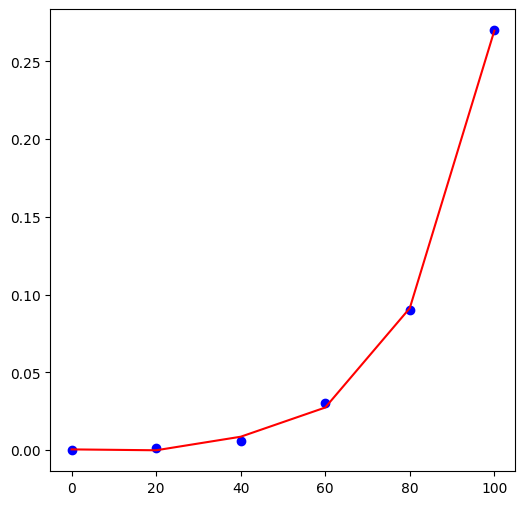

In [163]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(6,6))
plt.scatter(x,y,color='blue')
plt.plot(x,y_pred,color='red')
plt.show()

### car_data

In [197]:
df = pd.read_csv('car_data.csv')
df.head()

,Horsepower,Weight,MPG
0,130,3504,18
1,165,3693,15
2,150,3436,18
3,140,3433,16
4,198,4341,14


In [198]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Horsepower  9 non-null      int64
 1   Weight      9 non-null      int64
 2   MPG         9 non-null      int64
dtypes: int64(3)
memory usage: 348.0 bytes


In [199]:
df.columns

Index(['Horsepower', 'Weight', 'MPG'], dtype='object')

In [200]:
x = df[['Horsepower', 'Weight']]
y = df['MPG']

In [201]:
lr.fit(x,y)
y_pred = lr.predict(x)
y_pred

array([17.52306936, 16.24685654, 17.81577597, 17.88426886, 12.31560418,
       12.12775724, 24.27495677, 25.71591805, 25.09579304])

In [202]:
diff = pd.DataFrame({'Actual': y, 'Predicted': y_pred})
diff.head()

,Actual,Predicted
0,18,17.523069
1,15,16.246857
2,18,17.815776
3,16,17.884269
4,14,12.315604


In [203]:
print('Coreffiecnt',lr.coef_)
print('Intercept',lr.intercept_)

Coreffiecnt [-0.00510729 -0.00580665]
Intercept 38.53353251084853


In [204]:
print(f'MAE: {metrics.mean_absolute_error(y,y_pred)}')
print(f'MAS: {metrics.mean_squared_error(y,y_pred)}')
print(f'R2 Score: {metrics.r2_score(y,y_pred)}')

MAE: 0.9677057051428102
MAS: 1.2883721565386081
R2 Score: 0.9485920469558486


##### poly

In [205]:
df = pd.read_csv('car_data.csv')
df.head()

,Horsepower,Weight,MPG
0,130,3504,18
1,165,3693,15
2,150,3436,18
3,140,3433,16
4,198,4341,14


In [206]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Horsepower  9 non-null      int64
 1   Weight      9 non-null      int64
 2   MPG         9 non-null      int64
dtypes: int64(3)
memory usage: 348.0 bytes


In [207]:
df.isna().sum()

Horsepower    0
Weight        0
MPG           0
dtype: int64

In [213]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
x_poly = poly.fit_transform(x)
print(x_poly)

[[1.0000000e+00 1.3000000e+02 3.5040000e+03 1.6900000e+04 4.5552000e+05
  1.2278016e+07]
 [1.0000000e+00 1.6500000e+02 3.6930000e+03 2.7225000e+04 6.0934500e+05
  1.3638249e+07]
 [1.0000000e+00 1.5000000e+02 3.4360000e+03 2.2500000e+04 5.1540000e+05
  1.1806096e+07]
 [1.0000000e+00 1.4000000e+02 3.4330000e+03 1.9600000e+04 4.8062000e+05
  1.1785489e+07]
 [1.0000000e+00 1.9800000e+02 4.3410000e+03 3.9204000e+04 8.5951800e+05
  1.8844281e+07]
 [1.0000000e+00 2.2000000e+02 4.3540000e+03 4.8400000e+04 9.5788000e+05
  1.8957316e+07]
 [1.0000000e+00 9.5000000e+01 2.3720000e+03 9.0250000e+03 2.2534000e+05
  5.6263840e+06]
 [1.0000000e+00 8.8000000e+01 2.1300000e+03 7.7440000e+03 1.8744000e+05
  4.5369000e+06]
 [1.0000000e+00 9.8000000e+01 2.2280000e+03 9.6040000e+03 2.1834400e+05
  4.9639840e+06]]


In [219]:

x_train,x_test,y_train,y_test = train_test_split(x_poly,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)


(7, 6)
(7,)
(2, 6)
(2,)


In [220]:
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)
y_pred

array([25.53716178, 15.7560762 ])

In [221]:
print(f'R2 Score: {metrics.r2_score(y_test,y_pred)}')

R2 Score: 0.588996645942929


### representation

In [224]:
from torch import merge_type_from_type_comment
x = [1,2,3,4,5]
y=[1,4,9,16,25]

x=pd.DataFrame(x)
y=pd.Series(y)
poly = PolynomialFeatures(degree=2)
x_poly = poly.fit_transform(x)
model = LinearRegression()
model.fit(x_poly,y)
y_pred = model.predict(x_poly)

print('R2 Score: ',metrics.r2_score(y,y_pred))



R2 Score:  1.0


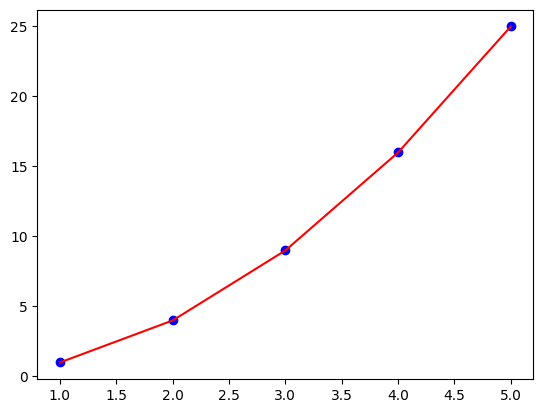

In [226]:
plt.scatter(x,y,color='blue')
plt.plot(x,y_pred,color='red')
plt.show()